# Iliad D.2 - Vanilla Policy Gradient & Goal Misgeneralisation

Runnable worked solutions. **Runtime -> Run all** trains a policy that solves CartPole.

Covers: policy-gradient theorem (log-derivative trick), REINFORCE, reward-to-go,
baselines/advantage, and the goal-misgeneralisation proxy-vs-goal idea.


## Setup

In [ ]:
!pip -q install gymnasium torch matplotlib

## Part 1 - Vanilla Policy Gradient

**Objective.** Policy $\pi_\theta(a\mid s)$, trajectory $\tau$, return $G(\tau)=\sum_t r_t$.
We maximise
$$ J(\theta)=\mathbb{E}_{\tau\sim\pi_\theta}[G(\tau)],\qquad
P(\tau\mid\theta)=\rho_0(s_0)\prod_t \pi_\theta(a_t\mid s_t)P(s_{t+1}\mid s_t,a_t).$$

**Policy gradient theorem.** Using $\nabla p = p\,\nabla\log p$ and noting the
environment terms carry no $\theta$:
$$ \boxed{\;\nabla_\theta J=\mathbb{E}_\tau\Big[\big(\textstyle\sum_t \nabla_\theta\log\pi_\theta(a_t\mid s_t)\big)\,G(\tau)\Big]\;}$$
No dynamics model needed. **Surrogate loss** $L=-\frac1N\sum_i\sum_t \log\pi_\theta(a^i_t\mid s^i_t)\,\hat G_t$
(minus sign: ascent on reward = descent on $-\log\pi\cdot G$).

**Reward-to-go** $\hat G_t=\sum_{t'\ge t} r_{t'}$ (an action can't affect past rewards: lower variance).
**Baseline/advantage** $A=\hat G_t-V(s_t)$; any $b(s)$ is unbiased since
$\mathbb{E}[\nabla\log\pi(a\mid s)\,b(s)]=b(s)\nabla\!\sum_a\pi=b(s)\nabla 1=0$.


In [1]:
import torch, torch.nn as nn, gymnasium as gym
from torch.distributions import Categorical
torch.manual_seed(0)

class Policy(nn.Module):
    def __init__(self, obs_dim, n_act, h=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim,h), nn.Tanh(),
                                 nn.Linear(h,h), nn.Tanh(), nn.Linear(h,n_act))
    def forward(self, x): return self.net(x)            # logits

def reward_to_go(rews):
    rtg=[0.0]*len(rews); run=0.0
    for t in reversed(range(len(rews))):
        run=rews[t]+run; rtg[t]=run
    return rtg

In [2]:
def train(epochs=60, batch_steps=2000, lr=1e-2):
    env=gym.make("CartPole-v1")
    pi=Policy(env.observation_space.shape[0], env.action_space.n)
    opt=torch.optim.Adam(pi.parameters(), lr=lr); curve=[]
    for ep in range(epochs):
        obs,act,w,rets=[],[],[],[]; steps=0
        while steps<batch_steps:
            o,_=env.reset(); er=[]; done=False
            while not done:
                a=Categorical(logits=pi(torch.as_tensor(o,dtype=torch.float32))).sample().item()
                obs.append(o); act.append(a)
                o,r,term,trunc,_=env.step(a); done=term or trunc
                er.append(r); steps+=1
            w+=reward_to_go(er); rets.append(sum(er))
        logp=Categorical(logits=pi(torch.as_tensor(obs,dtype=torch.float32))).log_prob(torch.as_tensor(act))
        wt=torch.as_tensor(w,dtype=torch.float32); wt=(wt-wt.mean())/(wt.std()+1e-8)  # baseline
        loss=-(logp*wt).mean()                                   # policy-gradient surrogate
        opt.zero_grad(); loss.backward(); opt.step()
        curve.append(sum(rets)/len(rets))
        if ep%10==0 or ep==epochs-1: print(f"epoch {ep:3d}  avg_return {curve[-1]:6.1f}")
    return curve

curve=train()
print("best avg_return =", round(max(curve)))

C:\Users\pavan\AppData\Local\Temp\ipykernel_18704\1048310206.py:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  logp=Categorical(logits=pi(torch.as_tensor(obs,dtype=torch.float32))).log_prob(torch.as_tensor(act))


epoch   0  avg_return   22.1


epoch  10  avg_return  383.3


epoch  20  avg_return  402.0


epoch  30  avg_return  500.0


epoch  40  avg_return  500.0


epoch  50  avg_return  460.4


epoch  59  avg_return  500.0
best avg_return = 500


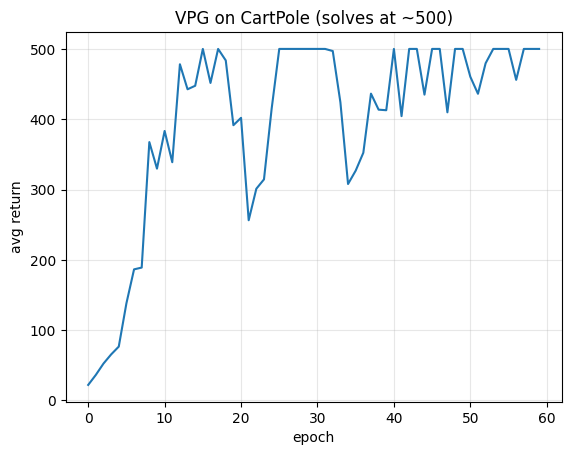

In [3]:
import matplotlib.pyplot as plt
plt.plot(curve); plt.xlabel("epoch"); plt.ylabel("avg return")
plt.title("VPG on CartPole (solves at ~500)"); plt.grid(alpha=.3); plt.show()

## Part 2 - Goal Misgeneralisation

**GMG:** the agent stays *capable* out of distribution but optimises an *unintended
goal* - with a *correct* reward on the training distribution. Not capability failure,
not reward misspecification.

**Why:** a *proxy* correlates with the true goal in training; SGD has no reason to
prefer the goal; at test the proxy and goal *decorrelate*. Canonical: **CoinRun** -
coin always at the right end in training -> agent learns "go right", not "get coin".

The probe (drop into a gridworld where coin is fixed-right in train, random at test):

In [4]:
def evaluate_gmg(agent, test_envs):
    """GMG <=> the agent reaches the PROXY (rightmost column) far more than the COIN."""
    coin=proxy=0
    for env in test_envs:
        tr=rollout(agent, env)                 # supply your gridworld rollout
        coin  += tr.ended_on(env.coin_pos)
        proxy += tr.ended_on(env.rightmost_column)
    n=len(test_envs); return coin/n, proxy/n
# Fix: retrain with RANDOMISED coin position (diverse distribution) -> coin>>proxy.

**Takeaway.** A correct reward is not sufficient for a correctly-generalising goal:
SGD's inductive bias + a narrow training distribution can install a competent agent
with the wrong objective. References: Sutton & Barto Ch.13; OpenAI Spinning Up VPG;
Langosco et al. 2021 (arXiv:2105.14111); Shah et al. 2022 (arXiv:2210.01790).